# Vector Data Cubes for Jokulsarlon Glacial Lake

This is a notebook to create a vector data cube (VDC) of the Jokulsarlon glacial lake outlines from 2016 to 2025 based on [original computational notebook](https://github.com/loreabad6/vdc-space-time-feats/blob/main/notebook/vdc-showcase.md) by Abad et al 2024.

**Input data:** `../OBIA_lake_outlines/glacial_lakes_<YYYY>.gpkg`  
**Fields per file:** `id`, `area_m2`, `year`, `geometry`  
**Temporal resolution:** one file per year, multiple polygons per file (one row per lake).

The difference from the lava-flow VDC is that **each lake is a separate feature** tracked across years,  
so the `geom_sum` dimension has one entry per lake (identified by `id`), not just one entry for a single feature.



**Prerequisites:**

Install environment:
```
conda env create -f env.yaml
```
Activate environment:
```
conda activate glacial_lakes
```
Register environment as Jupyter kernel, so it shows in drop down:
```
python -m ipykernel install --user --name glacial_lakes --display-name "glacial_lakes"
```
Update the environment **when finished with code**:
```
conda env export > env.yaml
```

In [2]:
from pathlib import Path

import numpy as np
import xvec
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union
from shapely import to_wkt
from shapely.affinity import affine_transform
import matplotlib.cm as cm

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data loading and pre-processing

### 1.1 Read all annual GeoPackages

Each file is named `glacial_lakes_<YYYY>.gpkg`.  
We extract the year from the filename and store it as an integer column `year_ts` (to avoid colliding with the existing `year` attribute field).

In [3]:
DATA_DIR = Path("C:/Users/b1120440/OneDrive - Universität Salzburg/MorphEO/data/OBIA_lake_outlines")

# Find all annual files and sort chronologically
gpkg_files = sorted(DATA_DIR.glob("glacial_lakes_*.gpkg"))
print(f"Found {len(gpkg_files)} files:")
for f in gpkg_files:
    print(f"  {f.name}")

Found 38 files:
  glacial_lakes_1985.gpkg
  glacial_lakes_1986.gpkg
  glacial_lakes_1987.gpkg
  glacial_lakes_1988.gpkg
  glacial_lakes_1989.gpkg
  glacial_lakes_1990.gpkg
  glacial_lakes_1991.gpkg
  glacial_lakes_1992.gpkg
  glacial_lakes_1993.gpkg
  glacial_lakes_1994.gpkg
  glacial_lakes_1995.gpkg
  glacial_lakes_1996.gpkg
  glacial_lakes_1997.gpkg
  glacial_lakes_1998.gpkg
  glacial_lakes_1999.gpkg
  glacial_lakes_2000.gpkg
  glacial_lakes_2001.gpkg
  glacial_lakes_2002.gpkg
  glacial_lakes_2004.gpkg
  glacial_lakes_2005.gpkg
  glacial_lakes_2006.gpkg
  glacial_lakes_2007.gpkg
  glacial_lakes_2010.gpkg
  glacial_lakes_2011.gpkg
  glacial_lakes_2012.gpkg
  glacial_lakes_2013.gpkg
  glacial_lakes_2014.gpkg
  glacial_lakes_2015.gpkg
  glacial_lakes_2016.gpkg
  glacial_lakes_2017.gpkg
  glacial_lakes_2018.gpkg
  glacial_lakes_2019.gpkg
  glacial_lakes_2020.gpkg
  glacial_lakes_2021.gpkg
  glacial_lakes_2022.gpkg
  glacial_lakes_2023.gpkg
  glacial_lakes_2024.gpkg
  glacial_lakes_2025.g

In [4]:
def read_lake_file(path: Path) -> gpd.GeoDataFrame:
    """
    Read a single annual glacial-lake GeoPackage.

    The year is extracted from the filename (glacial_lakes_YYYY.gpkg)
    and stored as an integer in the column `year_ts`.
    Expected attribute fields: id, area_m2, year, geometry.
    """
    gdf = gpd.read_file(path)
    # Extract year from filename as integer
    year_from_fn = int(path.stem.split("_")[-1])  # e.g. 'glacial_lakes_2016' -> 2016
    gdf["year_ts"] = year_from_fn
    gdf["source_file"] = path.name
    return gdf


# Read and concatenate all files
all_lakes = pd.concat([read_lake_file(p) for p in gpkg_files], ignore_index=True)
all_lakes = gpd.GeoDataFrame(all_lakes, geometry="geometry")

print(all_lakes.info())
print(f"\nYears present: {sorted(all_lakes['year_ts'].unique())}")

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   area_m2      193 non-null    float64 
 1   year         193 non-null    int64   
 2   geometry     193 non-null    geometry
 3   year_ts      193 non-null    int64   
 4   source_file  193 non-null    str     
dtypes: float64(1), geometry(1), int64(2), str(1)
memory usage: 7.7 KB
None

Years present: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)

In [5]:
print(all_lakes.groupby("year_ts").size())
print(all_lakes.head(20)[["year_ts", "area_m2", "geometry"]])

year_ts
1985    5
1986    6
1987    3
1988    9
1989    4
1990    3
1991    4
1992    3
1993    3
1994    5
1995    6
1996    5
1997    5
1998    5
1999    5
2000    6
2001    6
2002    4
2004    5
2005    6
2006    4
2007    7
2010    6
2011    3
2012    6
2013    5
2014    5
2015    7
2016    6
2017    5
2018    5
2019    5
2020    5
2021    5
2022    4
2023    6
2024    6
2025    5
dtype: int64
    year_ts    area_m2                                           geometry
0      1985   947700.0  POLYGON ((735450 7117050, 735450 7116870, 7354...
1      1985   611100.0  POLYGON ((737100 7116540, 737100 7116510, 7370...
2      1985  9367200.0  POLYGON ((734040 7114620, 734040 7114560, 7340...
3      1985  5228100.0  POLYGON ((726090 7112670, 726090 7112640, 7260...
4      1985   494100.0  POLYGON ((725730 7107900, 725730 7107870, 7257...
5      1986   405000.0  POLYGON ((735840 7119330, 735840 7119300, 7357...
6      1986  2501100.0  POLYGON ((736080 7117830, 736080 7117800, 7360...
7      

### 1.2 Check CRS and reproject if needed

All files should share the same CRS. We reproject everything to a consistent projected CRS for metric calculations.
Adjust the EPSG code below to match your study area (e.g. a local UTM zone).

In [6]:
print(f"Native CRS: {all_lakes.crs}")

# Set target CRS — change EPSG if needed for your region
# For example: 32632 (UTM 32N, Central Europe), 32654 (UTM 54N, High Asia), etc.
TARGET_CRS = all_lakes.crs  # Keep native CRS by default; replace with e.g. 32632

if all_lakes.crs is None:
    raise ValueError("CRS is missing. Set it explicitly: all_lakes = all_lakes.set_crs(<EPSG>)")

all_lakes = all_lakes.to_crs(TARGET_CRS)
print(f"Working CRS: {all_lakes.crs}")

Native CRS: EPSG:32627
Working CRS: EPSG:32627


### 1.3 Validate and fix geometries

In [7]:
invalid = (~all_lakes.geometry.is_valid).sum()
print(f"Invalid geometries before fix: {invalid}")
all_lakes["geometry"] = all_lakes["geometry"].make_valid()
print(f"Invalid geometries after fix:  {(~all_lakes.geometry.is_valid).sum()}")

Invalid geometries before fix: 0
Invalid geometries after fix:  0


Assign ID for each lake based on spatial overlap or proximity over the years. First year each lake gets an ID. Lakes in the following years are matched to the nearest lake from the previous years if within threshold. If lake is outside threshold, the lake gets a new ID.

In [8]:
def assign_lake_ids(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = 500) -> gpd.GeoDataFrame:
    """
    Assign consistent lake IDs across years based on spatial overlap or proximity.
    Lakes in the first year get IDs 1, 2, 3...
    Each subsequent year, a polygon is matched to the nearest prior-year lake
    if within distance_threshold_m; otherwise it gets a new ID.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1  # placeholder

    next_id = 1

    # Assign IDs to the first year
    first_year_mask = all_lakes["year_ts"] == years[0]
    n_first = first_year_mask.sum()
    all_lakes.loc[first_year_mask, "id"] = range(next_id, next_id + n_first)
    next_id += n_first

    # For each subsequent year, match to previous year by overlap then proximity
    for yr in years[1:]:
        curr_mask = all_lakes["year_ts"] == yr
        curr_idx = all_lakes[curr_mask].index

        # All lakes assigned so far (previous years)
        prev = all_lakes[all_lakes["id"] != -1].copy()

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # 1. Try overlap first
            overlapping = prev[prev.intersects(geom)]
            if not overlapping.empty:
                # Pick the one with the largest intersection area
                best_id = overlapping.copy()
                best_id["overlap"] = overlapping.geometry.intersection(geom).area
                assigned_id = best_id.loc[best_id["overlap"].idxmax(), "id"]
            else:
                # 2. Fall back to nearest within threshold
                distances = prev.geometry.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = prev.loc[distances.idxmin(), "id"]
                else:
                    # 3. New lake — assign a new ID
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)

    return all_lakes


all_lakes = assign_lake_ids(all_lakes, distance_threshold_m=400)

# Check result
print(all_lakes[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes.groupby('year_ts')['id'].nunique()}")

     year_ts  id       area_m2
0       1985   1  9.477000e+05
6       1986   1  2.501100e+06
15      1988   1  3.024000e+05
16      1988   1  6.246000e+05
17      1988   1  4.356000e+05
30      1991   1  2.871000e+05
34      1992   1  4.662000e+05
37      1993   1  1.921500e+06
1       1985   2  6.111000e+05
18      1988   2  5.148000e+05
24      1989   2  5.103000e+05
31      1991   2  4.122000e+05
41      1994   2  3.870000e+05
46      1995   2  3.762000e+05
52      1996   2  3.843000e+05
57      1997   2  3.798000e+05
62      1998   2  3.870000e+05
66      1999   2  3.897000e+05
71      2000   2  3.987000e+05
79      2001   2  3.420000e+05
83      2002   2  3.780000e+05
88      2004   2  3.609000e+05
93      2005   2  2.277000e+05
98      2006   2  3.636000e+05
111     2010   2  3.474000e+05
119     2012   2  3.744000e+05
125     2013   2  3.726000e+05
130     2014   2  3.627000e+05
135     2015   2  3.627000e+05
141     2016   2  6.826920e+05
147     2017   2  4.029276e+05
152     

### 1.4 Explore the data

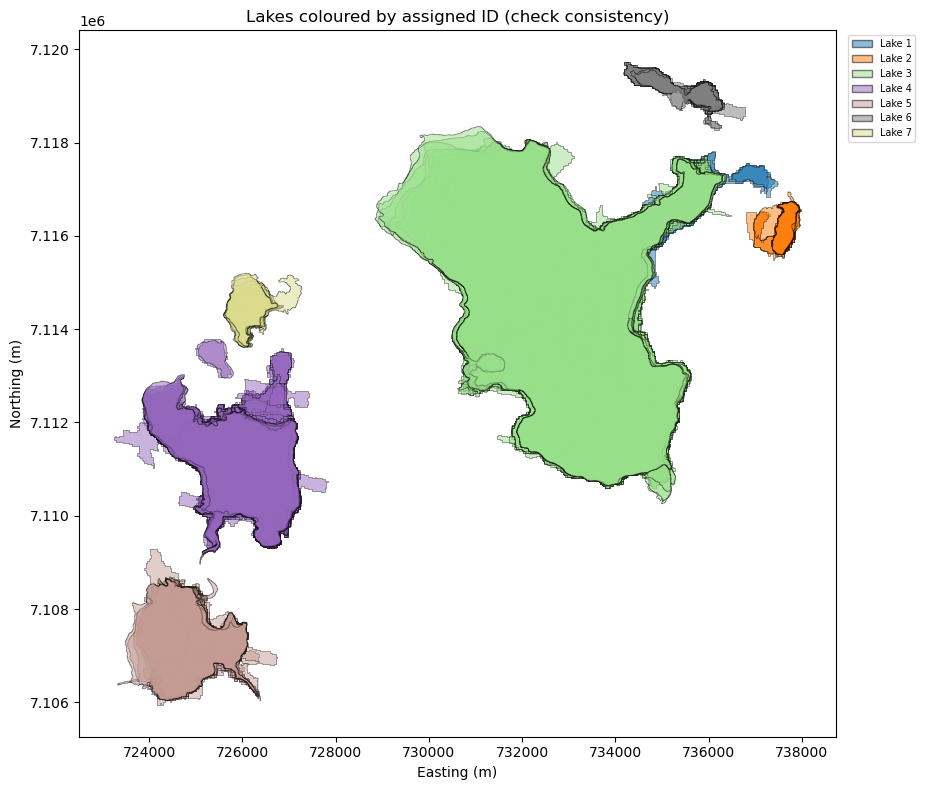

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes["id"].unique())  # now "id" exists
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes[all_lakes["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Lakes coloured by assigned ID (check consistency)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 1.5 Prepare per-lake, per-year geometry

Because each `.gpkg` can contain **multiple polygons** (one per lake), we now have a long-format GeoDataFrame
with one row per (`id`, `year_ts`) combination.

If the same lake id appears more than once in a single year (e.g. fragmented polygons),
we union them into a single geometry per (`id`, `year_ts`).

In [10]:
# Union polygons with the same id within the same year, then reset index
outlines = (
    all_lakes
    .groupby(["id", "year_ts"], as_index=False)
    .agg(
        geometry=("geometry", lambda g: unary_union(g)),
        area_m2=("area_m2", "sum"),      # sum fragmented-polygon areas
    )
)
outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes.crs)
outlines["geometry"] = outlines["geometry"].make_valid()

print(f"Rows after aggregation: {len(outlines)}  (expected: n_lakes × n_years)")
print(outlines.head())

Rows after aggregation: 174  (expected: n_lakes × n_years)
   id  year_ts                                           geometry    area_m2
0   1     1985  POLYGON ((735450 7117050, 735450 7116870, 7354...   947700.0
1   1     1986  POLYGON ((736080 7117830, 736080 7117800, 7360...  2501100.0
2   1     1988  MULTIPOLYGON (((735000 7116630, 735000 7116600...  1362600.0
3   1     1991  POLYGON ((736770 7117530, 736770 7117500, 7367...   287100.0
4   1     1992  POLYGON ((735390 7117140, 735390 7117110, 7353...   466200.0


### 1.6 Check for missing (lake, year) combinations

Not every lake may be present in every year. The VDC needs a fully populated grid,
so we identify gaps and fill them with `None` geometries.

In [11]:
lake_ids = sorted(outlines["id"].unique())
year_list = sorted(outlines["year_ts"].unique())

# Full grid of (id, year) combinations
full_index = pd.MultiIndex.from_product([lake_ids, year_list], names=["id", "year_ts"])
current_index = pd.MultiIndex.from_frame(outlines[["id", "year_ts"]])
missing = full_index.difference(current_index)

if len(missing) == 0:
    print("No missing (lake, year) combinations — grid is complete.")
else:
    print(f"Missing combinations: {len(missing)}")
    print(missing.to_frame(index=False).to_string())
    # Fill missing rows with None geometry
    fill_rows = pd.DataFrame(
        [{"id": i, "year_ts": y, "geometry": None, "area_m2": np.nan} for i, y in missing],
    )
    fill_gdf = gpd.GeoDataFrame(fill_rows, geometry="geometry", crs=outlines.crs)
    outlines = pd.concat([outlines, fill_gdf], ignore_index=True)
    outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes.crs)
    outlines = outlines.sort_values(["id", "year_ts"]).reset_index(drop=True)
    print("\nFilled missing entries with None geometry.")

Missing combinations: 92
    id  year_ts
0    1     1987
1    1     1989
2    1     1990
3    1     1994
4    1     1995
5    1     1996
6    1     1997
7    1     1998
8    1     1999
9    1     2000
10   1     2001
11   1     2002
12   1     2004
13   1     2005
14   1     2006
15   1     2007
16   1     2010
17   1     2011
18   1     2012
19   1     2013
20   1     2014
21   1     2015
22   1     2016
23   1     2017
24   1     2018
25   1     2019
26   1     2020
27   1     2021
28   1     2022
29   1     2023
30   1     2024
31   1     2025
32   2     1986
33   2     1987
34   2     1990
35   2     1992
36   2     1993
37   2     2007
38   2     2011
39   3     1991
40   3     2022
41   5     1989
42   5     1990
43   5     1992
44   5     1993
45   5     2000
46   5     2011
47   6     1985
48   6     1987
49   6     1991
50   6     1992
51   6     1993
52   6     1999
53   6     2000
54   6     2002
55   6     2006
56   6     2007
57   6     2016
58   6     2017
59   6     2018

## 2. VDC creation

### 2.1 Compute summary geometries (one per lake)

In the lava-flow example there was a single feature, so the `geom_sum` dimension had size 1.
Here we have **one summary geometry per lake** — we use the centroid of the union of all its yearly outlines.

In [12]:
# Summary geometry per lake: centroid of the union of all yearly polygons
summary_geoms = (
    outlines.dropna(subset=["geometry"])   # ignore missing-year rows
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).centroid)
)
summary_geoms = gpd.GeoSeries(summary_geoms, crs=all_lakes.crs)

print("Summary geometries (centroids) per lake:")
print(summary_geoms)

Summary geometries (centroids) per lake:
id
1    POINT (735496.473 7116638.817)
2    POINT (737413.589 7116181.994)
3    POINT (732660.429 7114663.695)
4    POINT (725788.258 7111443.232)
5    POINT (724784.193 7107346.814)
6      POINT (735475.227 7119067.2)
7    POINT (726296.869 7114509.705)
Name: geometry, dtype: geometry


### 2.2 Array format VDC

The data array has shape **(n_lakes × n_years)** where:
- `geom_sum` dimension = one centroid per lake (size = number of unique lakes)
- `year` dimension = one entry per year

Each cell contains the changing polygon geometry of that lake in that year.

In [13]:
# Build a 2-D array: rows = lakes (ordered by id), cols = years
geom_matrix = np.empty((len(lake_ids), len(year_list)), dtype=object)

for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) == 0 or row.iloc[0].geometry is None:
            geom_matrix[i, j] = None
        else:
            geom_matrix[i, j] = row.iloc[0].geometry

# Summary geometry list in the same order as lake_ids
centroid_list = [summary_geoms.loc[lid] for lid in lake_ids]

# EPSG code as integer for xvec
crs_epsg = all_lakes.crs.to_epsg()

# Build the xarray DataArray
cube_arr = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="geometry",
).xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_arr)

<xarray.DataArray 'geometry' (geom_sum: 7, year: 38)> Size: 2kB
array([[<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
        <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
        None,
        <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
        None, None,
        <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
        <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
        <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None],
       [<POLYGON ((737100 7116540, 737100 7116510, 737070 7116510, 737070 7116480, 7...>,
        None, None,
        <POLYGON ((737070 7116510, 737070 7116480, 73

### 2.3 Add `area_m2` as a second data variable

The VDC can carry multiple variables. Here we attach the measured `area_m2`
as an additional coordinate/variable alongside the geometry.
This turns the structure into an `xr.Dataset` (≈ a multi-variable cube).

In [14]:
# Build area array WITHOUT setting a geometry index
area_matrix = np.full((len(lake_ids), len(year_list)), np.nan)

# Fill with values
for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) > 0 and not pd.isna(row.iloc[0]["area_m2"]):
            area_matrix[i, j] = row.iloc[0]["area_m2"]

area_arr = xr.DataArray(
    data=area_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="area_m2",
)

# Rebuild cube_arr WITHOUT geometry index first
cube_arr_plain = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="geometry",
)

# Combine into Dataset first, then set geometry index once
cube_ds = xr.Dataset({"geometry": cube_arr_plain, "area_m2": area_arr})
cube_ds = cube_ds.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

# Keep indexed cube_arr separately if needed downstream
cube_arr = cube_arr_plain.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_ds)

<xarray.Dataset> Size: 5kB
Dimensions:   (geom_sum: 7, year: 38)
Coordinates:
  * geom_sum  (geom_sum) object 56B POINT (735496.4726918075 7116638.81664499...
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
Data variables:
    geometry  (geom_sum, year) object 2kB POLYGON ((735450 7117050, 735450 71...
    area_m2   (geom_sum, year) float64 2kB 9.477e+05 2.501e+06 ... 8.905e+05
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)


### 2.4 Tabular format VDC (spatial + temporal faces)

Mirrors the cubble `face_spatial` / `face_temporal` pattern from the original notebook.

In [15]:
# Spatial face: one row per lake, with its summary (centroid) geometry
spatial_face = gpd.GeoDataFrame(
    {
        "id": lake_ids,
        "geom_sum": centroid_list,
    },
    geometry="geom_sum",
    crs=all_lakes.crs,
)

# Temporal face: one row per (lake_id, year) with changing geometry + attributes
temporal_face = outlines[["id", "year_ts", "area_m2", "geometry"]].copy()
temporal_face = gpd.GeoDataFrame(temporal_face, geometry="geometry", crs=all_lakes.crs)

print("=== Spatial face ===")
print(spatial_face)
print("\n=== Temporal face (first 15 rows) ===")
print(temporal_face.head(15).to_string())

=== Spatial face ===
   id                        geom_sum
0   1  POINT (735496.473 7116638.817)
1   2  POINT (737413.589 7116181.994)
2   3  POINT (732660.429 7114663.695)
3   4  POINT (725788.258 7111443.232)
4   5  POINT (724784.193 7107346.814)
5   6    POINT (735475.227 7119067.2)
6   7  POINT (726296.869 7114509.705)

=== Temporal face (first 15 rows) ===
    id  year_ts    area_m2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [16]:
print(temporal_face)

     id  year_ts       area_m2  \
0     1     1985  9.477000e+05   
1     1     1986  2.501100e+06   
2     1     1987           NaN   
3     1     1988  1.362600e+06   
4     1     1989           NaN   
..   ..      ...           ...   
261   7     2021  8.403616e+05   
262   7     2022  8.729986e+05   
263   7     2023  1.241424e+06   
264   7     2024  9.105412e+05   
265   7     2025  8.905186e+05   

                                              geometry  
0    POLYGON ((735450 7117050, 735450 7116870, 7354...  
1    POLYGON ((736080 7117830, 736080 7117800, 7360...  
2                                                 None  
3    MULTIPOLYGON (((735000 7116630, 735000 7116600...  
4                                                 None  
..                                                 ...  
261  POLYGON ((726212.642 7114964.048, 726213.583 7...  
262  POLYGON ((726175.227 7115040.915, 726176.168 7...  
263  POLYGON ((726108.869 7115104.996, 726109.81 71...  
264  POLYGON ((725963

In [17]:
print(cube_arr)

<xarray.DataArray 'geometry' (geom_sum: 7, year: 38)> Size: 2kB
array([[<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
        <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
        None,
        <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
        None, None,
        <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
        <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
        <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None],
       [<POLYGON ((737100 7116540, 737100 7116510, 737070 7116510, 737070 7116480, 7...>,
        None, None,
        <POLYGON ((737070 7116510, 737070 7116480, 73

## 3. Exploration and analysis

### 3.1 Select a single lake from the cube

In [18]:
# Example: select the first lake by position
lake_slice = cube_arr.isel(geom_sum=0)
print(f"Lake ID: {lake_ids[3]}")
print(lake_slice)

Lake ID: 4
<xarray.DataArray 'geometry' (year: 38)> Size: 304B
array([<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
       <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
       None,
       <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
       None, None,
       <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
       <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
       <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None], dtype=object)
Coordinates:
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
    geom_sum  object 8B POINT (735496.4726918075 7116638.816644994)

### 3.2 Area time series per lake

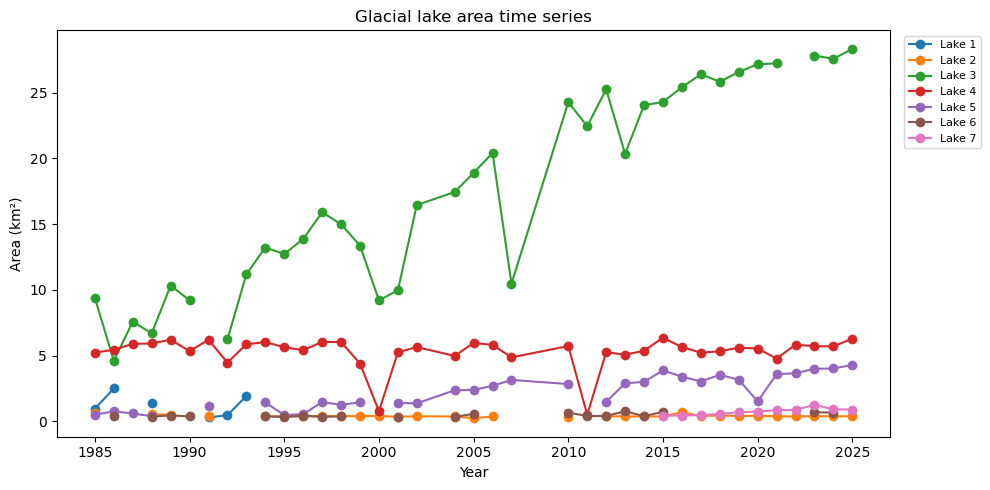

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, lid in enumerate(lake_ids):
    subset = temporal_face[temporal_face["id"] == lid].sort_values("year_ts")
    ax.plot(
        subset["year_ts"],
        subset["area_m2"] / 1e6,  # convert to km²
        marker="o",
        label=f"Lake {lid}",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")
ax.set_title("Glacial lake area time series")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_area_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 3.3 Total lake area per year

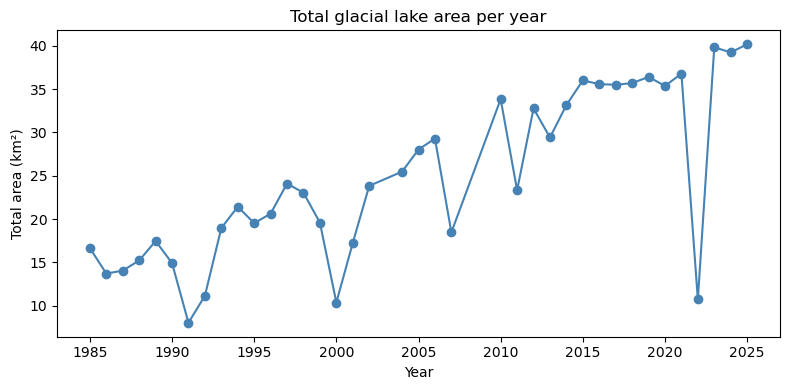

year_ts
1985    16.648200
1986    13.703400
1987    14.051700
1988    15.219900
1989    17.465400
1990    14.914800
1991     8.026200
1992    11.151900
1993    18.963900
1994    21.428100
1995    19.518300
1996    20.623500
1997    24.098400
1998    23.030100
1999    19.578600
2000    10.365300
2001    17.249400
2002    23.830200
2004    25.467300
2005    28.025100
2006    29.283300
2007    18.465300
2010    33.831900
2011    23.328900
2012    32.763600
2013    29.411100
2014    33.152400
2015    35.997300
2016    35.571765
2017    35.495827
2018    35.685670
2019    36.404239
2020    35.359337
2021    36.777915
2022    10.719706
2023    39.822581
2024    39.228956
2025    40.170898
Name: area_m2, dtype: float64


In [20]:
total_area = (
    temporal_face.groupby("year_ts")["area_m2"]
    .sum()
    / 1e6  # km²
)

fig, ax = plt.subplots(figsize=(8, 4))
total_area.plot(ax=ax, marker="o", color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Total area (km²)")
ax.set_title("Total glacial lake area per year")
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_total_area.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(total_area)

### 3.4 Save the VDC Dataset

Geometry variables are stored as WKT before writing to NetCDF (xarray cannot serialise Shapely objects natively).

In [21]:
# Convert geometry cells and index to WKT for serialisation
wkt_geoms = np.vectorize(
    lambda g: to_wkt(g) if g is not None else ""
)(geom_matrix)

wkt_centroids = [to_wkt(c) for c in centroid_list]

ds_nc = xr.Dataset(
    {
        "geometry_wkt": xr.DataArray(
            wkt_geoms,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "area_m2": xr.DataArray(
            area_matrix,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "centroid_wkt": xr.DataArray(
            wkt_centroids,
            dims=["lake_id"],
            coords={"lake_id": lake_ids},
        ),
    }
)
ds_nc.attrs["crs"] = str(all_lakes.crs)
ds_nc.attrs["description"] = "Glacial lake VDC — geometry stored as WKT"

out_nc = Path("C:/Users/b1120440/morpheo/glacial_lakes_cube.nc") # path to Drive didn't work
ds_nc.to_netcdf(out_nc)
print(f"VDC saved to {out_nc}")

VDC saved to C:\Users\b1120440\morpheo\glacial_lakes_cube.nc


In [22]:
print(temporal_face.geometry.total_bounds)  # minx, miny, maxx, maxy
print(f"X range: {temporal_face.geometry.total_bounds[2] - temporal_face.geometry.total_bounds[0]:.0f} m")
print(f"Y range: {temporal_face.geometry.total_bounds[3] - temporal_face.geometry.total_bounds[1]:.0f} m")


[ 723240.         7105950.          737994.89289625 7119720.        ]
X range: 14755 m
Y range: 13770 m


C:\Users\b1120440\AppData\Local\Temp\ipykernel_18468\1134193851.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))


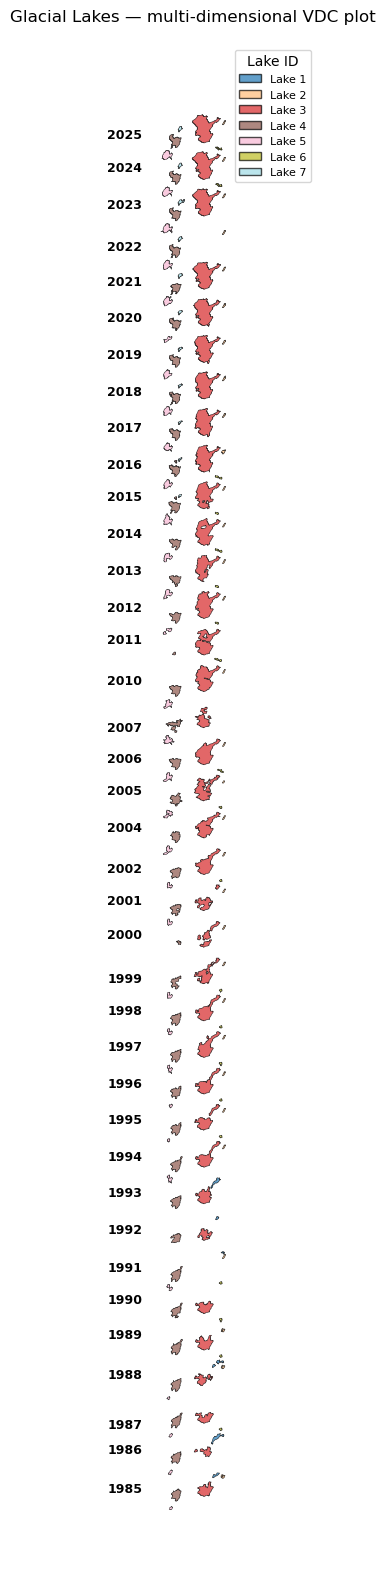

In [23]:
# --- Shear parameters (adjust to taste) ---
a, b_, d, e = 1.0, 0.3, 0.0, 1.0

# Vertical spacing between years (in CRS units = metres)
# Increase if polygons overlap, decrease if too spread out
Y_SPACING = 10_000

all_years = sorted(temporal_face["year_ts"].unique())
year_to_idx = {yr: i + 1 for i, yr in enumerate(all_years)}

# --- Apply shear + vertical shift to each polygon ---
lakes_shear = []
for _, row in temporal_face.iterrows():
    if row["geometry"] is None or row.geometry.is_empty:
        continue
    geom = row["geometry"]
    # Apply shear
    geom_s = affine_transform(geom, [a, b_, d, e, 0, 0])
    # Shift vertically by year index
    shift_y = year_to_idx[row["year_ts"]] * Y_SPACING
    geom_shifted = affine_transform(geom_s, [1, 0, 0, 1, 0, shift_y])
    lakes_shear.append({
        "id": row["id"],
        "year_ts": row["year_ts"],
        "geometry": geom_shifted,
    })

lakes_shear_gdf = gpd.GeoDataFrame(lakes_shear, geometry="geometry")

# --- Colour mapping: one colour per lake ID ---
lake_ids_sorted = sorted(lakes_shear_gdf["id"].unique())
cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))
id_to_color = {lid: cmap_lakes(i) for i, lid in enumerate(lake_ids_sorted)}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 16))

for _, row in lakes_shear_gdf.iterrows():
    color = id_to_color[row["id"]]
    gpd.GeoSeries([row["geometry"]]).plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=0.4, alpha=0.7
    )

# --- Year labels on the left ---
# Place label at the vertical centre of each year's polygons
for yr in all_years:
    sub = lakes_shear_gdf[lakes_shear_gdf["year_ts"] == yr]
    if sub.empty:
        continue
    y_label = sub["geometry"].centroid.y.mean()
    x_label = lakes_shear_gdf["geometry"].bounds["minx"].min() - 5_000
    ax.text(x_label, y_label, str(yr), fontsize=9, va="center", ha="right", fontweight="bold")

# --- Legend for lake IDs ---
legend_handles = [
    Patch(facecolor=id_to_color[lid], edgecolor="k", alpha=0.7, label=f"Lake {lid}")
    for lid in lake_ids_sorted
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Lake ID")

ax.set_title("Glacial Lakes — multi-dimensional VDC plot")
ax.axis("off")
plt.tight_layout()
plt.savefig('../data/output/glacial_lakes_VDC_plot.png', bbox_inches='tight', dpi=150, pad_inches=0)
plt.show()
plt.close()